In [13]:
# Sanskrit Character Classification using MLP
# Step 1: Install required libraries

!pip install -q pandas numpy matplotlib seaborn scikit-learn pillow joblib

In [14]:
# Import required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
# Step 3: Download the Devanagari Character Dataset

import os

# Download dataset directly
!wget -q https://archive.ics.uci.edu/static/public/389/devanagari+handwritten+character+dataset.zip \
    -O devanagari_dataset.zip

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [16]:
# Step 4: Extract dataset

import zipfile
import os

with zipfile.ZipFile("devanagari_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("devanagari_dataset")

print("Dataset extracted successfully!")

# Show extracted files
for root, dirs, files in os.walk("devanagari_dataset"):
    print(root, len(files), "files")
    if files:
        print("Sample files:", files[:5])

Dataset extracted successfully!
devanagari_dataset 0 files
devanagari_dataset/DevanagariHandwrittenCharacterDataset 0 files
devanagari_dataset/DevanagariHandwrittenCharacterDataset/Test 0 files
devanagari_dataset/DevanagariHandwrittenCharacterDataset/Test/character_27_ra 300 files
Sample files: ['62091.png', '51673.png', '82658.png', '51611.png', '62138.png']
devanagari_dataset/DevanagariHandwrittenCharacterDataset/Test/character_36_gya 300 files
Sample files: ['27524.png', '75054.png', '27426.png', '97927.png', '84012.png']
devanagari_dataset/DevanagariHandwrittenCharacterDataset/Test/digit_8 300 files
Sample files: ['56700.png', '68335.png', '5822.png', '78867.png', '42039.png']
devanagari_dataset/DevanagariHandwrittenCharacterDataset/Test/character_13_daa 300 files
Sample files: ['10675.png', '71979.png', '79883.png', '31664.png', '69458.png']
devanagari_dataset/DevanagariHandwrittenCharacterDataset/Test/character_28_la 300 files
Sample files: ['14455.png', '50507.png', '13156.png',

In [17]:
# STEP 5: Load and preprocess the character images

import os
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder

DATASET_PATH = "devanagari_dataset/DevanagariHandwrittenCharacterDataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "Train")
TEST_PATH = os.path.join(DATASET_PATH, "Test")

IMAGE_SIZE = (32, 32)

def load_images(folder_path):
    images = []
    labels = []

    for class_name in sorted(os.listdir(folder_path)):

        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if filename.lower().endswith((".png", ".jpg", ".jpeg")):

                image_path = os.path.join(class_path, filename)

                try:
                    image = Image.open(image_path).convert("L")
                    image = image.resize(IMAGE_SIZE)

                    image_array = np.array(image, dtype=np.float32)

                    # Normalize pixels from 0-255 to 0-1
                    image_array = image_array / 255.0

                    # Convert 32x32 image into 1024 numerical features
                    image_vector = image_array.flatten()

                    images.append(image_vector)
                    labels.append(class_name)

                except Exception as e:
                    print("Error loading:", image_path, e)

    return np.array(images), np.array(labels)


print("Loading training images...")
X_train = None
y_train = None

X_train, y_train = load_images(TRAIN_PATH)

print("Training data loaded!")
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("\nLoading testing images...")

X_test, y_test = load_images(TEST_PATH)

print("Testing data loaded!")
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Loading training images...
Training data loaded!
Training images: (78200, 1024)
Training labels: (78200,)

Loading testing images...
Testing data loaded!
Testing images: (13800, 1024)
Testing labels: (13800,)


In [18]:
# STEP 6: Encode character labels

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Number of character classes:", len(label_encoder.classes_))

print("\nCharacter classes:")
for i, character in enumerate(label_encoder.classes_):
    print(i, ":", character)

Number of character classes: 46

Character classes:
0 : character_10_yna
1 : character_11_taamatar
2 : character_12_thaa
3 : character_13_daa
4 : character_14_dhaa
5 : character_15_adna
6 : character_16_tabala
7 : character_17_tha
8 : character_18_da
9 : character_19_dha
10 : character_1_ka
11 : character_20_na
12 : character_21_pa
13 : character_22_pha
14 : character_23_ba
15 : character_24_bha
16 : character_25_ma
17 : character_26_yaw
18 : character_27_ra
19 : character_28_la
20 : character_29_waw
21 : character_2_kha
22 : character_30_motosaw
23 : character_31_petchiryakha
24 : character_32_patalosaw
25 : character_33_ha
26 : character_34_chhya
27 : character_35_tra
28 : character_36_gya
29 : character_3_ga
30 : character_4_gha
31 : character_5_kna
32 : character_6_cha
33 : character_7_chha
34 : character_8_ja
35 : character_9_jha
36 : digit_0
37 : digit_1
38 : digit_2
39 : digit_3
40 : digit_4
41 : digit_5
42 : digit_6
43 : digit_7
44 : digit_8
45 : digit_9


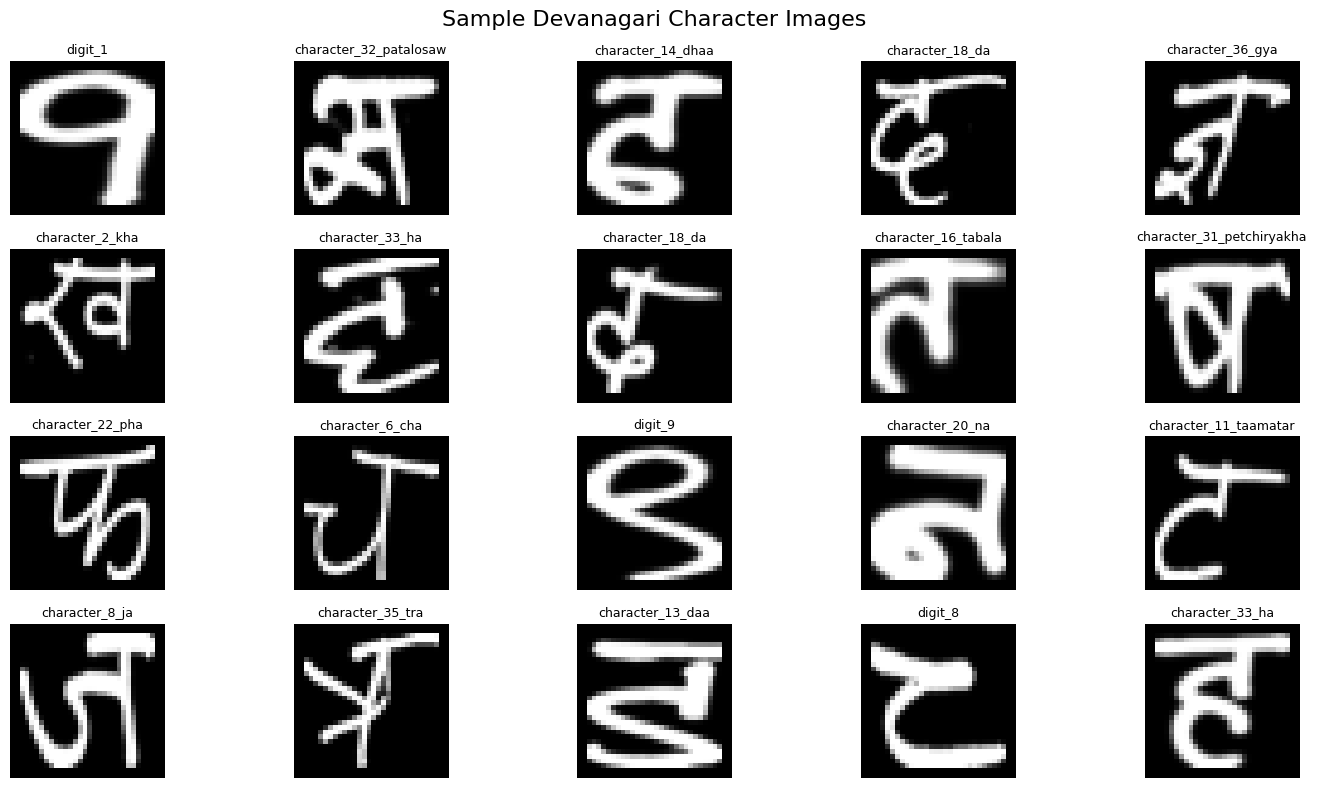

In [19]:
# STEP 7: Visualize sample Devanagari characters

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 8))

# Select 20 random training images
np.random.seed(42)
indices = np.random.choice(len(X_train), 20, replace=False)

for i, idx in enumerate(indices):

    # Convert 1024 features back to 32 x 32 image
    image = X_train[idx].reshape(32, 32)

    # Get original character name
    character = y_train[idx]

    plt.subplot(4, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(character, fontsize=9)
    plt.axis("off")

plt.suptitle(
    "Sample Devanagari Character Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [20]:
# STEP 8: Build and train the MLP classifier

from sklearn.neural_network import MLPClassifier

print("Starting MLP training...")
print("Training samples:", X_train.shape[0])
print("Features per image:", X_train.shape[1])
print("Number of classes:", len(label_encoder.classes_))

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=True
)

mlp.fit(X_train, y_train_encoded)

print("\nMLP TRAINING COMPLETED!")
print("Iterations:", mlp.n_iter_)

Starting MLP training...
Training samples: 78200
Features per image: 1024
Number of classes: 46
Iteration 1, loss = 1.15748189
Validation score: 0.823018
Iteration 2, loss = 0.49115428
Validation score: 0.878005
Iteration 3, loss = 0.32738125
Validation score: 0.889898
Iteration 4, loss = 0.24549927
Validation score: 0.908568
Iteration 5, loss = 0.19615127
Validation score: 0.914066
Iteration 6, loss = 0.15240624
Validation score: 0.917263
Iteration 7, loss = 0.12487256
Validation score: 0.921995
Iteration 8, loss = 0.10161263
Validation score: 0.922506
Iteration 9, loss = 0.08594089
Validation score: 0.923913
Iteration 10, loss = 0.07053587
Validation score: 0.919821
Iteration 11, loss = 0.06037186
Validation score: 0.929540
Iteration 12, loss = 0.05424188
Validation score: 0.924936
Iteration 13, loss = 0.04559662
Validation score: 0.927366
Iteration 14, loss = 0.04677921
Validation score: 0.930818
Iteration 15, loss = 0.04664417
Validation score: 0.923402
Iteration 16, loss = 0.03954

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [21]:
# STEP 9: Evaluate the MLP model

print("Evaluating MLP model on unseen test data...\n")

# Make predictions
y_pred = mlp.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test_encoded, y_pred)

precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 45)
print("       MLP CLASSIFICATION RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")

print("=" * 45)

Evaluating MLP model on unseen test data...

       MLP CLASSIFICATION RESULTS
Accuracy  : 93.91%
Precision : 94.00%
Recall    : 93.91%
F1-Score  : 93.92%


In [22]:
# STEP 10: Detailed classification report

print("Detailed Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Detailed Classification Report:

                           precision    recall  f1-score   support

         character_10_yna       0.91      0.96      0.94       300
    character_11_taamatar       0.96      0.95      0.95       300
        character_12_thaa       0.98      0.94      0.96       300
         character_13_daa       0.94      0.91      0.92       300
        character_14_dhaa       0.93      0.95      0.94       300
        character_15_adna       0.94      0.98      0.96       300
      character_16_tabala       0.97      0.92      0.94       300
         character_17_tha       0.88      0.90      0.89       300
          character_18_da       0.89      0.91      0.90       300
         character_19_dha       0.86      0.91      0.89       300
           character_1_ka       0.99      0.98      0.98       300
          character_20_na       0.90      0.92      0.91       300
          character_21_pa       0.91      0.95      0.93       300
         character_22_pha   

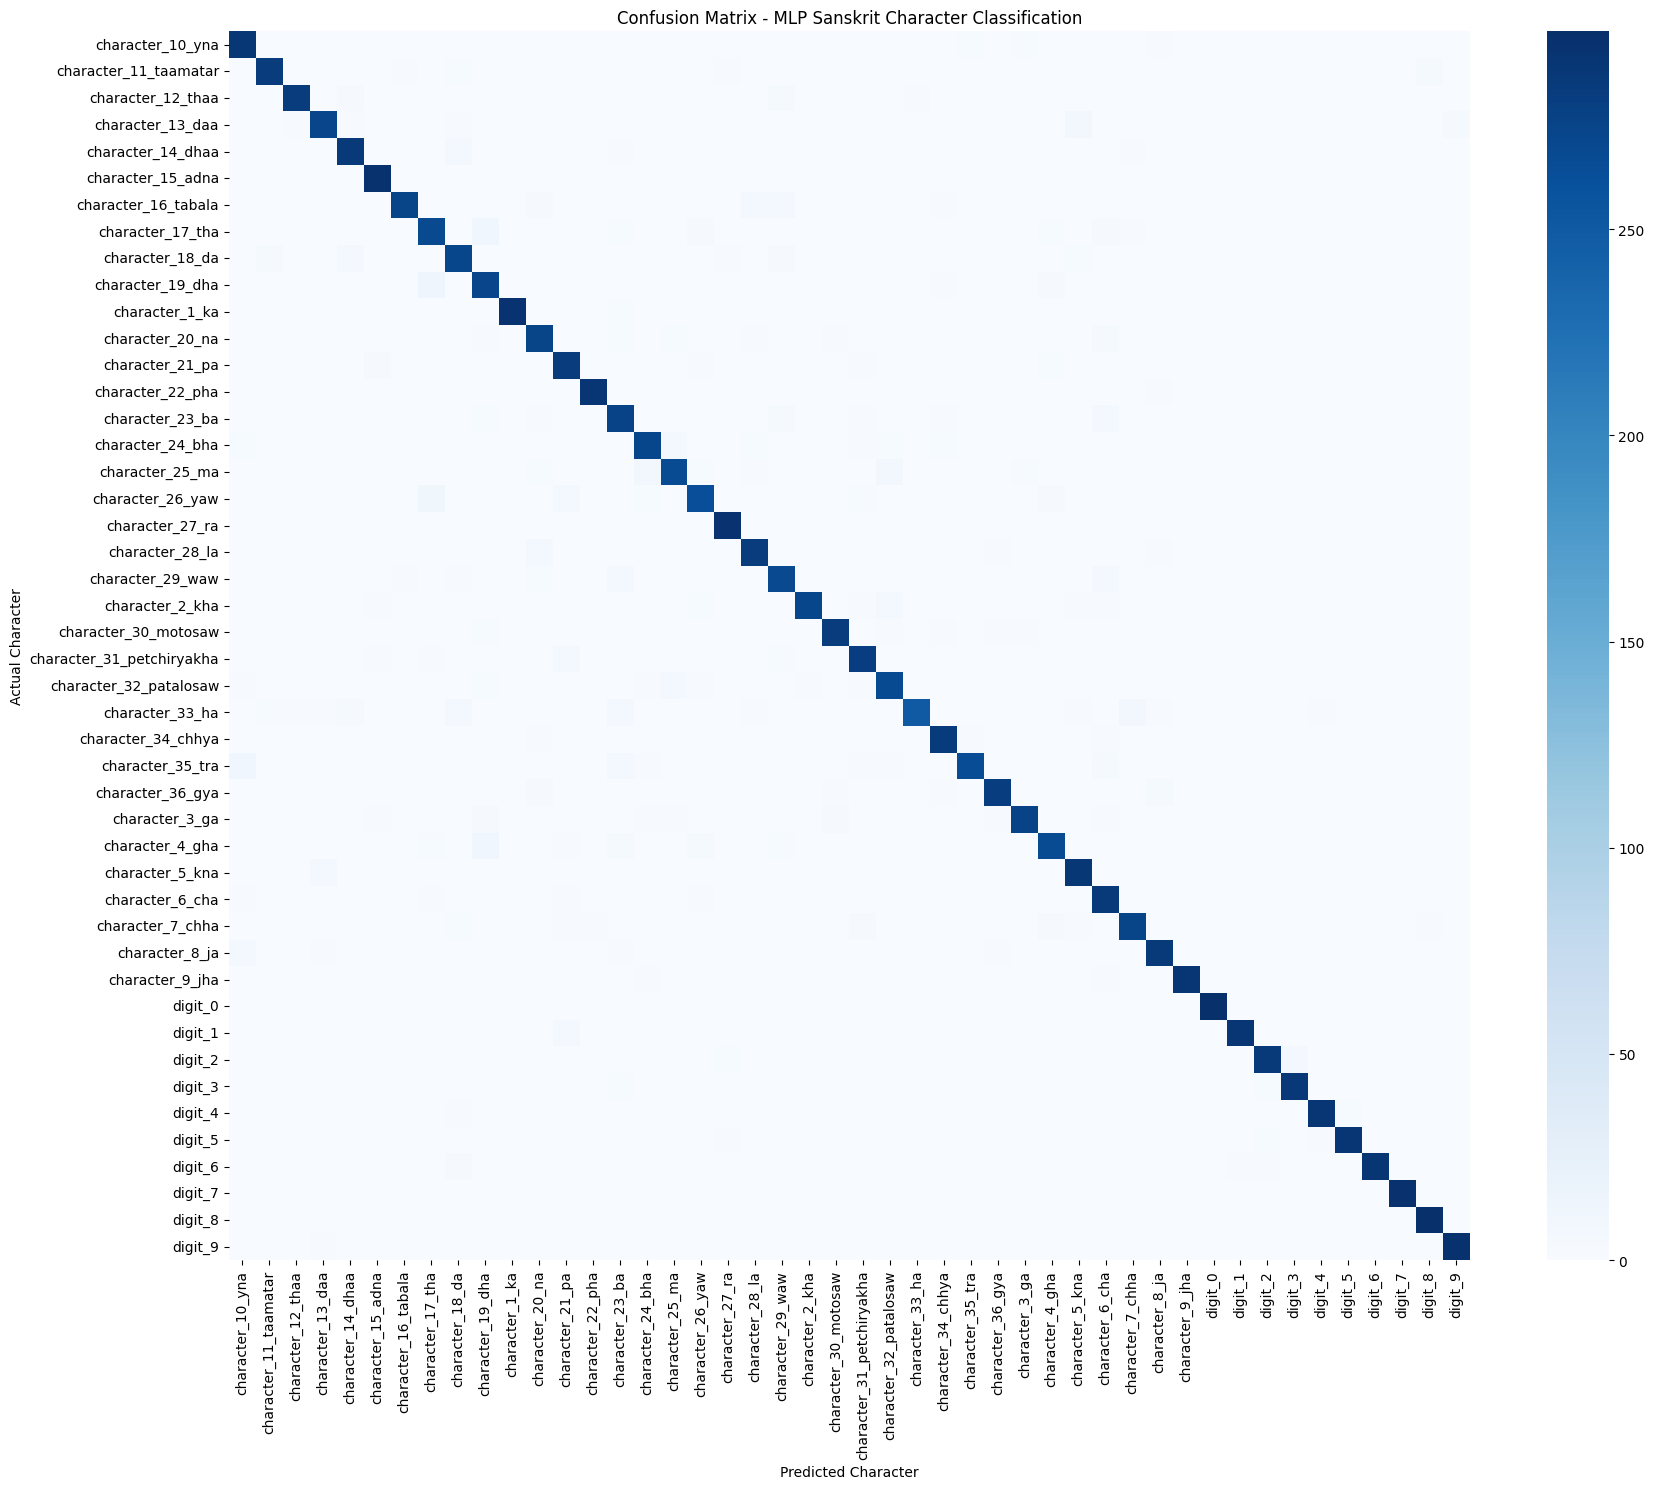

In [23]:
# STEP 11: Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - MLP Sanskrit Character Classification")
plt.xlabel("Predicted Character")
plt.ylabel("Actual Character")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

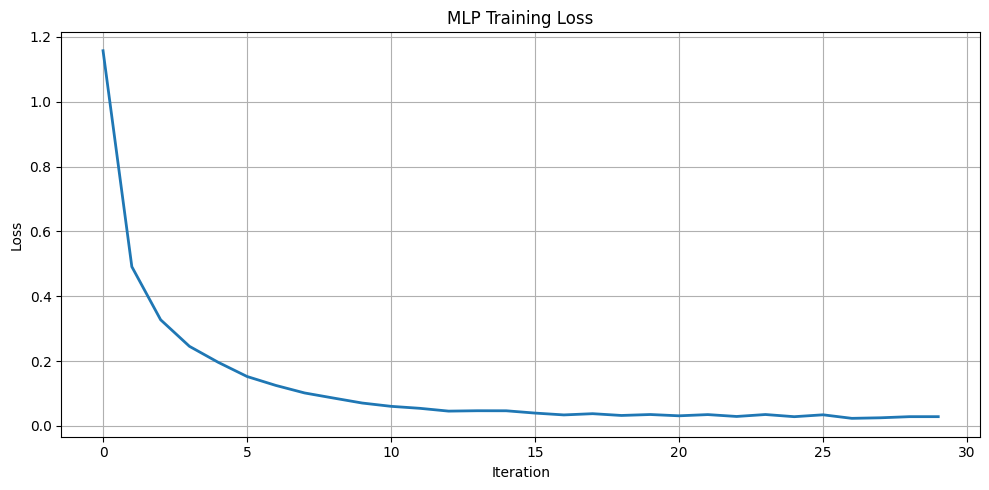

In [24]:
# STEP 12: Training Loss Curve

plt.figure(figsize=(10, 5))

plt.plot(
    mlp.loss_curve_,
    linewidth=2
)

plt.title("MLP Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

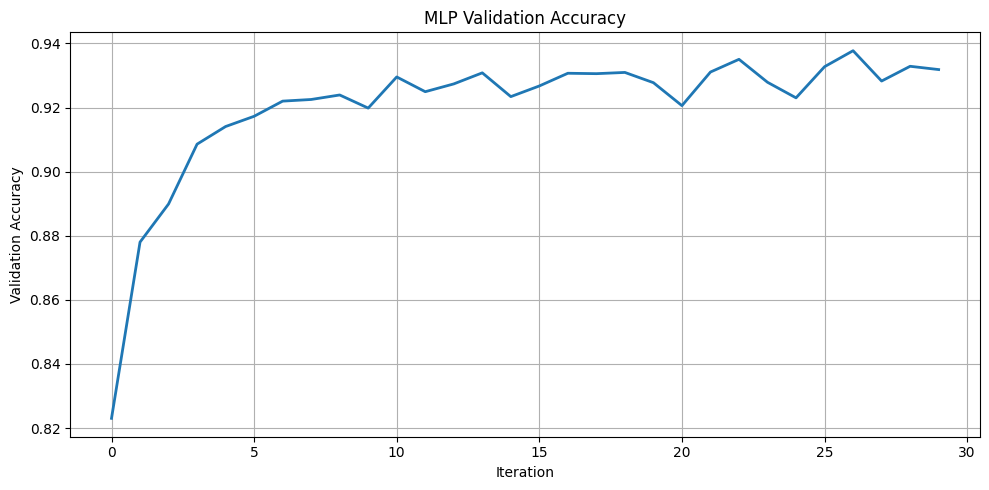

In [25]:
# STEP 13: Validation Accuracy Curve

plt.figure(figsize=(10, 5))

plt.plot(
    mlp.validation_scores_,
    linewidth=2
)

plt.title("MLP Validation Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Validation Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# STEP 14: Final Test Performance

y_pred = mlp.predict(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(
    y_test_encoded, y_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_test_encoded, y_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_test_encoded, y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 50)
print("       FINAL MLP TEST RESULTS")
print("=" * 50)
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")
print("=" * 50)

       FINAL MLP TEST RESULTS
Accuracy  : 93.91%
Precision : 94.00%
Recall    : 93.91%
F1-Score  : 93.92%


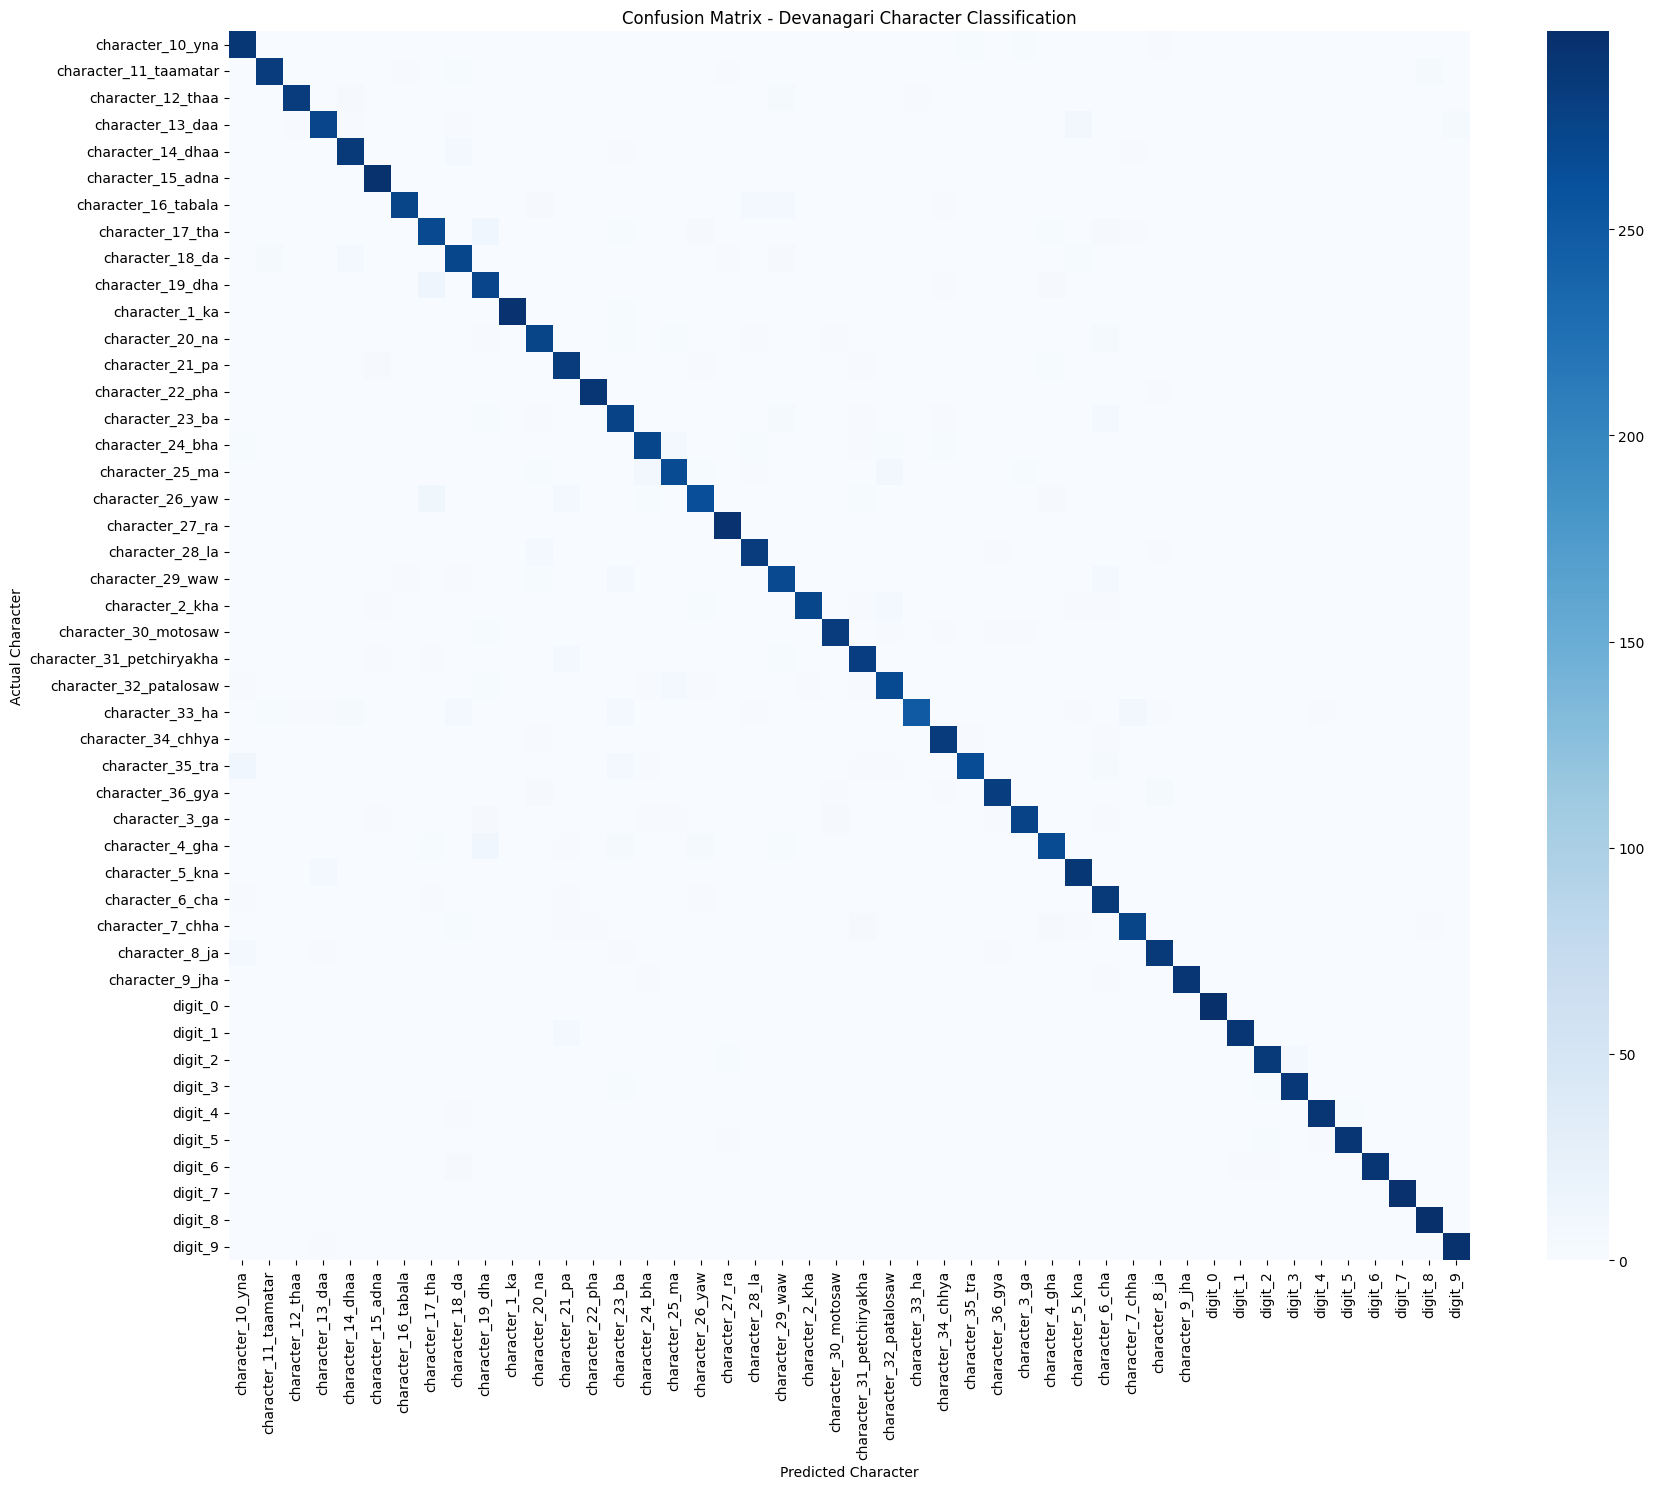

In [27]:
# STEP 15: Confusion Matrix

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Devanagari Character Classification")
plt.xlabel("Predicted Character")
plt.ylabel("Actual Character")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

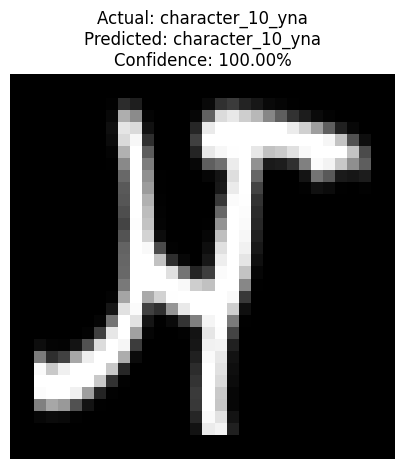

CHARACTER PREDICTION RESULT
Actual Character    : character_10_yna
Predicted Character : character_10_yna
Confidence          : 100.00%


In [28]:
# STEP 16: Predict a test character

sample_index = 0

sample_vector = X_test[sample_index].reshape(1, 1024)
sample_image = X_test[sample_index].reshape(32, 32)

prediction = mlp.predict(sample_vector)

predicted_character = label_encoder.inverse_transform(
    prediction
)[0]

actual_character = label_encoder.inverse_transform(
    [y_test_encoded[sample_index]]
)[0]

probabilities = mlp.predict_proba(sample_vector)[0]
confidence = np.max(probabilities) * 100

plt.figure(figsize=(5, 5))
plt.imshow(sample_image, cmap="gray")

plt.title(
    f"Actual: {actual_character}\n"
    f"Predicted: {predicted_character}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

print("=" * 50)
print("CHARACTER PREDICTION RESULT")
print("=" * 50)
print("Actual Character    :", actual_character)
print("Predicted Character :", predicted_character)
print(f"Confidence          : {confidence:.2f}%")
print("=" * 50)

In [29]:
print("X_test exists:", "X_test" in globals())
print("mlp exists:", "mlp" in globals())
print("label_encoder exists:", "label_encoder" in globals())
print("y_test_encoded exists:", "y_test_encoded" in globals())

X_test exists: True
mlp exists: True
label_encoder exists: True
y_test_encoded exists: True


In [30]:
# STEP 17: Save trained model and label encoder

import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    mlp,
    "models/sanskrit_mlp.pkl"
)

joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
)

print("========================================")
print("MODEL SAVING COMPLETED")
print("========================================")
print("MLP model saved as:")
print("models/sanskrit_mlp.pkl")
print()
print("Label encoder saved as:")
print("models/label_encoder.pkl")
print("========================================")

MODEL SAVING COMPLETED
MLP model saved as:
models/sanskrit_mlp.pkl

Label encoder saved as:
models/label_encoder.pkl


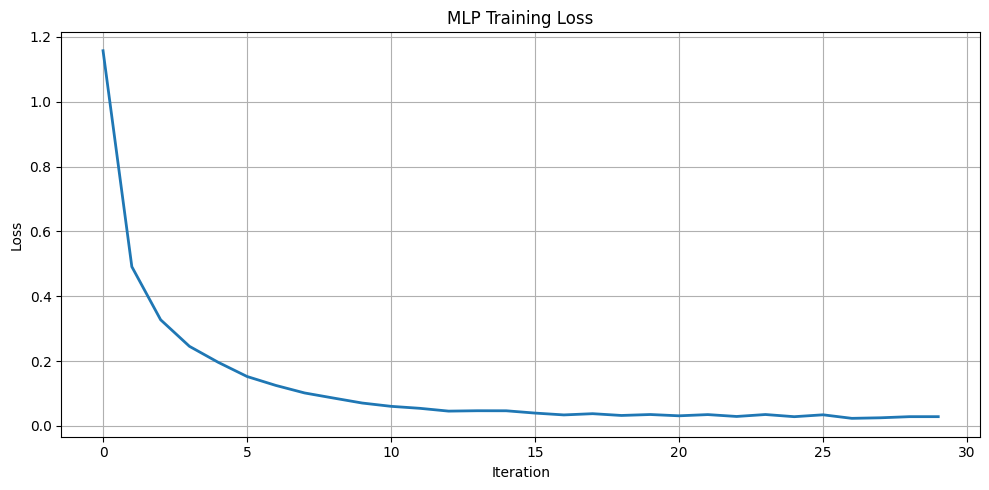

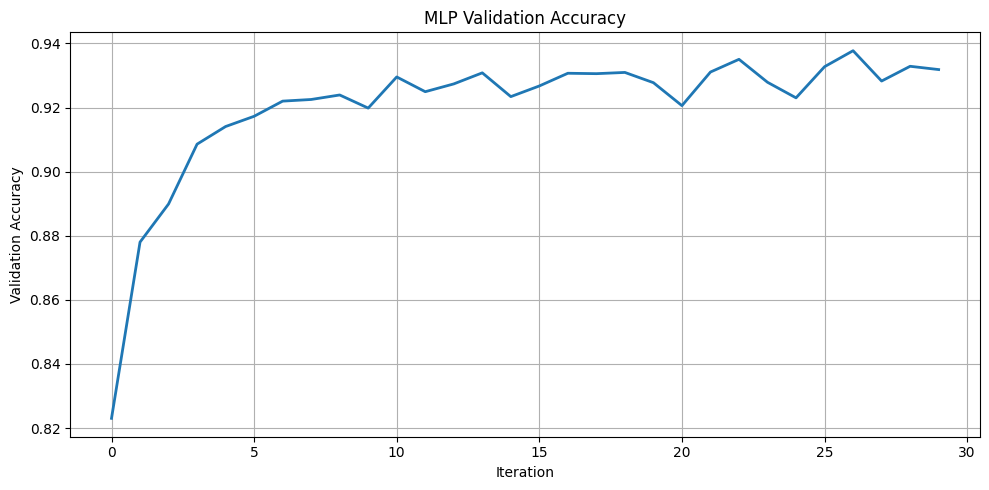

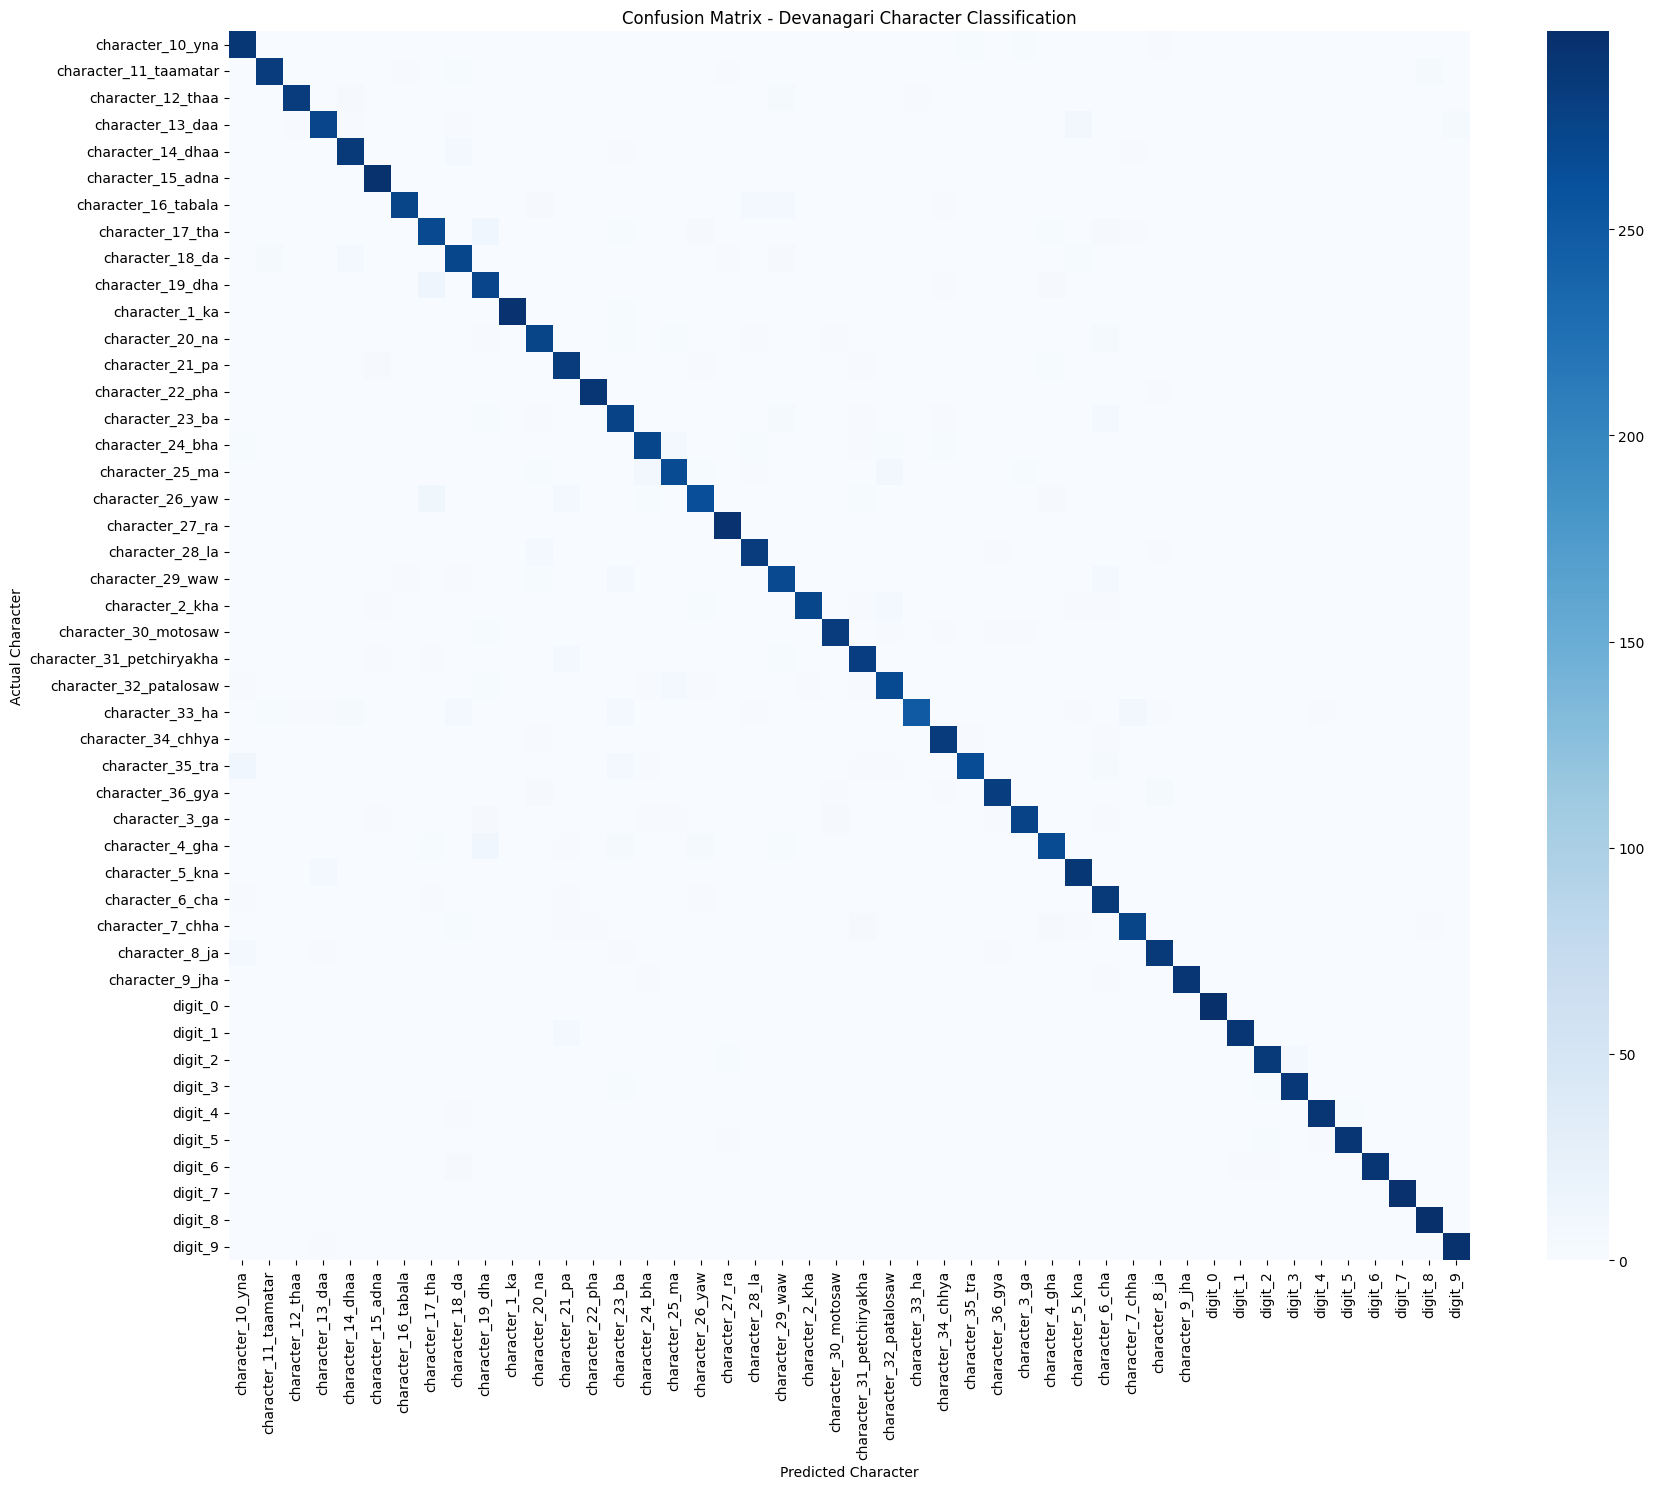

VISUALIZATIONS SAVED SUCCESSFULLY
outputs/training_loss.png
outputs/validation_accuracy.png
outputs/confusion_matrix.png


In [31]:
# STEP 18: Save project visualizations

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create output folder
os.makedirs("outputs", exist_ok=True)

# ----------------------------------------
# 1. Training Loss
# ----------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    mlp.loss_curve_,
    linewidth=2
)

plt.title("MLP Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "outputs/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------------------
# 2. Validation Accuracy
# ----------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    mlp.validation_scores_,
    linewidth=2
)

plt.title("MLP Validation Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Validation Accuracy")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "outputs/validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------------------
# 3. Confusion Matrix
# ----------------------------------------

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Devanagari Character Classification")
plt.xlabel("Predicted Character")
plt.ylabel("Actual Character")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "outputs/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 50)
print("VISUALIZATIONS SAVED SUCCESSFULLY")
print("=" * 50)
print("outputs/training_loss.png")
print("outputs/validation_accuracy.png")
print("outputs/confusion_matrix.png")
print("=" * 50)

In [32]:
# STEP 19: Final Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Generate predictions on the complete test dataset
y_pred = mlp.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_encoded, y_pred)

precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

# Display final results
print("=" * 60)
print("        SANSKRIT CHARACTER MLP CLASSIFICATION")
print("                 FINAL EVALUATION")
print("=" * 60)

print(f"Number of Character Classes : {len(label_encoder.classes_)}")
print(f"Test Samples                : {len(X_test)}")
print(f"Training Iterations         : {mlp.n_iter_}")

print("-" * 60)

print(f"Accuracy                    : {accuracy * 100:.2f}%")
print(f"Precision                   : {precision * 100:.2f}%")
print(f"Recall                      : {recall * 100:.2f}%")
print(f"F1-Score                    : {f1 * 100:.2f}%")

print("=" * 60)
print("Model evaluation completed successfully!")
print("=" * 60)

        SANSKRIT CHARACTER MLP CLASSIFICATION
                 FINAL EVALUATION
Number of Character Classes : 46
Test Samples                : 13800
Training Iterations         : 30
------------------------------------------------------------
Accuracy                    : 93.91%
Precision                   : 94.00%
Recall                      : 93.91%
F1-Score                    : 93.92%
Model evaluation completed successfully!
